In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats

PROCESSED = Path("/content/drive/MyDrive/bluestock_mf_capstone/data/processed")

# Load cleaned nav and benchmark
nav = pd.read_csv(PROCESSED / "02_nav_history_clean.csv", parse_dates=['date'])
bench = pd.read_csv(PROCESSED / "10_benchmark_indices_clean.csv", parse_dates=['date'])
fund = pd.read_csv(PROCESSED / "01_fund_master_clean.csv")

print(f"NAV shape: {nav.shape}")
print(f"Benchmark shape: {bench.shape}")
print(f"Fund master shape: {fund.shape}")

Mounted at /content/drive
NAV shape: (64320, 3)
Benchmark shape: (8050, 3)
Fund master shape: (40, 15)


In [2]:
# Compute daily returns for all 40 schemes
nav = nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

# Validate distribution
print("Daily Return Statistics:")
print(nav['daily_return'].describe())

# Check for anomalies
print(f"\nNulls in daily_return: {nav['daily_return'].isnull().sum()}")
print(f"Extreme returns (>20% or <-20%): {((nav['daily_return'] > 0.2) | (nav['daily_return'] < -0.2)).sum()}")

Daily Return Statistics:
count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64

Nulls in daily_return: 40
Extreme returns (>20% or <-20%): 0


In [3]:
# CAGR calculation
def compute_cagr(group, years):
    end_date = group['date'].max()
    start_date = end_date - pd.DateOffset(years=years)
    subset = group[group['date'] >= start_date]
    if len(subset) < 2:
        return np.nan
    nav_start = subset.iloc[0]['nav']
    nav_end = subset.iloc[-1]['nav']
    n_days = (subset.iloc[-1]['date'] - subset.iloc[0]['date']).days
    n_years = n_days / 365.25
    if n_years <= 0 or nav_start <= 0:
        return np.nan
    return (nav_end / nav_start) ** (1 / n_years) - 1

cagr_rows = []
for code, group in nav.groupby('amfi_code'):
    cagr_rows.append({
        'amfi_code': code,
        'cagr_1yr': compute_cagr(group, 1),
        'cagr_3yr': compute_cagr(group, 3),
        'cagr_5yr': compute_cagr(group, 5),
    })

cagr_df = pd.DataFrame(cagr_rows)
cagr_df = cagr_df.merge(fund[['amfi_code', 'scheme_name', 'fund_house']], on='amfi_code')

print("CAGR Comparison Table:")
print(cagr_df[['scheme_name', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr']].to_string(index=False))

CAGR Comparison Table:
                                          scheme_name  cagr_1yr  cagr_3yr  cagr_5yr
            HDFC Top 100 Fund - Regular Plan - Growth -0.022258  0.012924  0.026371
         HDFC Short Term Debt Fund - Regular - Growth  0.037076  0.039155  0.044582
   HDFC Mid-Cap Opportunities Fund - Regular - Growth  0.532772  0.324340  0.301232
        ABSL Frontline Equity Fund - Regular - Growth  0.479638  0.289602  0.235384
               ABSL Small Cap Fund - Regular - Growth -0.240003 -0.041515  0.079388
                  ABSL Liquid Fund - Regular - Growth  0.072418  0.063143  0.065090
           UTI Nifty 50 Index Fund - Regular - Growth  0.202229  0.196624  0.182324
                  UTI Mid Cap Fund - Regular - Growth -0.168080 -0.007672  0.011717
                UTI Flexi Cap Fund - Regular - Growth  0.135930  0.255497  0.168411
       Nippon India Large Cap Fund - Regular - Growth  0.340079  0.226466  0.240495
        Nippon India Large Cap Fund - Direct - Growth

In [4]:
# Sharpe Ratio
Rf = 0.065 / 252  # Daily risk-free rate (6.5% annual)

sharpe_rows = []
for code, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    excess = returns - Rf
    sharpe = (excess.mean() / returns.std()) * np.sqrt(252)
    sharpe_rows.append({'amfi_code': code, 'sharpe_ratio': sharpe})

sharpe_df = pd.DataFrame(sharpe_rows)
sharpe_df = sharpe_df.merge(fund[['amfi_code', 'scheme_name']], on='amfi_code')
sharpe_df = sharpe_df.sort_values('sharpe_ratio', ascending=False).reset_index(drop=True)

print("Sharpe Ratio Rankings:")
print(sharpe_df[['scheme_name', 'sharpe_ratio']].to_string(index=False))

Sharpe Ratio Rankings:
                                          scheme_name  sharpe_ratio
        Mirae Asset Large Cap Fund - Regular - Growth      1.068224
               Kotak Flexicap Fund - Regular - Growth      0.965561
        Mirae Asset Tax Saver Fund - Regular - Growth      0.919047
             ICICI Pru Midcap Fund - Regular - Growth      0.883256
            SBI Bluechip Fund - Regular Plan - Growth      0.860977
                   DSP Midcap Fund - Regular - Growth      0.832885
   HDFC Mid-Cap Opportunities Fund - Regular - Growth      0.808268
       Nippon India Large Cap Fund - Regular - Growth      0.758851
                  Axis Midcap Fund - Regular - Growth      0.730547
        ABSL Frontline Equity Fund - Regular - Growth      0.717409
            ICICI Pru Bluechip Fund - Direct - Growth      0.714682
                DSP Small Cap Fund - Regular - Growth      0.714422
           SBI Small Cap Fund - Regular Plan - Growth      0.711690
             SBI Bluechip

In [5]:
# Sortino Ratio
sortino_rows = []
for code, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    excess = returns - Rf
    downside = returns[returns < 0]
    downside_std = downside.std()
    sortino = (excess.mean() / downside_std) * np.sqrt(252) if downside_std > 0 else np.nan
    sortino_rows.append({'amfi_code': code, 'sortino_ratio': sortino})

sortino_df = pd.DataFrame(sortino_rows)
sortino_df = sortino_df.merge(fund[['amfi_code', 'scheme_name']], on='amfi_code')
sortino_df = sortino_df.sort_values('sortino_ratio', ascending=False).reset_index(drop=True)

print("Sortino Ratio Rankings:")
print(sortino_df[['scheme_name', 'sortino_ratio']].to_string(index=False))

Sortino Ratio Rankings:
                                          scheme_name  sortino_ratio
        Mirae Asset Large Cap Fund - Regular - Growth       1.490739
               Kotak Flexicap Fund - Regular - Growth       1.479503
        Mirae Asset Tax Saver Fund - Regular - Growth       1.352815
            SBI Bluechip Fund - Regular Plan - Growth       1.291483
             ICICI Pru Midcap Fund - Regular - Growth       1.285843
                   DSP Midcap Fund - Regular - Growth       1.167793
   HDFC Mid-Cap Opportunities Fund - Regular - Growth       1.144216
       Nippon India Large Cap Fund - Regular - Growth       1.098880
           SBI Small Cap Fund - Regular Plan - Growth       1.067256
            ICICI Pru Bluechip Fund - Direct - Growth       1.063964
        ABSL Frontline Equity Fund - Regular - Growth       1.063909
                  Axis Midcap Fund - Regular - Growth       1.055284
                DSP Small Cap Fund - Regular - Growth       1.030962
Mirae Asse

In [6]:
# Alpha and Beta using OLS regression against Nifty 100
nifty100 = bench[bench['index_name'] == 'NIFTY100'].copy()
nifty100 = nifty100.sort_values('date').reset_index(drop=True)
nifty100['bench_return'] = nifty100['close_value'].pct_change()

ab_rows = []
for code, group in nav.groupby('amfi_code'):
    group = group.sort_values('date')
    merged = pd.merge(group[['date', 'daily_return']],
                      nifty100[['date', 'bench_return']], on='date')
    merged = merged.dropna()
    if len(merged) < 30:
        continue
    slope, intercept, r, p, se = stats.linregress(
        merged['bench_return'], merged['daily_return']
    )
    ab_rows.append({
        'amfi_code': code,
        'beta': slope,
        'alpha': intercept * 252,
        'r_squared': r**2
    })

ab_df = pd.DataFrame(ab_rows)
ab_df = ab_df.merge(fund[['amfi_code', 'scheme_name']], on='amfi_code')
ab_df = ab_df.sort_values('alpha', ascending=False).reset_index(drop=True)

print("Alpha & Beta Rankings:")
print(ab_df[['scheme_name', 'alpha', 'beta', 'r_squared']].to_string(index=False))

Alpha & Beta Rankings:
                                          scheme_name    alpha      beta    r_squared
           SBI Small Cap Fund - Regular Plan - Growth 0.303370 -0.023196 1.414258e-04
                DSP Small Cap Fund - Regular - Growth 0.300579  0.011455 3.532991e-05
             ICICI Pru Midcap Fund - Regular - Growth 0.292636  0.000549 1.345534e-07
        Mirae Asset Tax Saver Fund - Regular - Growth 0.282704  0.018134 1.748889e-04
               Kotak Flexicap Fund - Regular - Growth 0.273305 -0.022830 3.430543e-04
   HDFC Mid-Cap Opportunities Fund - Regular - Growth 0.271954  0.005104 1.206652e-05
        Mirae Asset Large Cap Fund - Regular - Growth 0.269838  0.023684 4.625437e-04
                   DSP Midcap Fund - Regular - Growth 0.265986 -0.002523 3.357978e-06
                  Axis Midcap Fund - Regular - Growth 0.260767 -0.066265 1.936879e-03
            SBI Bluechip Fund - Regular Plan - Growth 0.232010 -0.031751 8.869789e-04
       Nippon India Large Cap F

In [7]:
# Maximum Drawdown
dd_rows = []
for code, group in nav.groupby('amfi_code'):
    group = group.sort_values('date')
    nav_series = group['nav']
    rolling_max = nav_series.cummax()
    drawdown = (nav_series / rolling_max) - 1
    max_dd = drawdown.min()
    max_dd_date = group['date'].iloc[drawdown.argmin()]
    dd_rows.append({
        'amfi_code': code,
        'max_drawdown': max_dd,
        'max_dd_date': max_dd_date
    })

dd_df = pd.DataFrame(dd_rows)
dd_df = dd_df.merge(fund[['amfi_code', 'scheme_name']], on='amfi_code')
dd_df = dd_df.sort_values('max_drawdown').reset_index(drop=True)

print("Maximum Drawdown Rankings (worst first):")
print(dd_df[['scheme_name', 'max_drawdown', 'max_dd_date']].to_string(index=False))

Maximum Drawdown Rankings (worst first):
                                          scheme_name  max_drawdown max_dd_date
            SBI Small Cap Fund - Direct Plan - Growth     -0.525742  2025-10-28
               Axis Small Cap Fund - Regular - Growth     -0.516778  2026-05-11
               ABSL Small Cap Fund - Regular - Growth     -0.354469  2026-05-11
                DSP Small Cap Fund - Regular - Growth     -0.311719  2025-01-03
           SBI Small Cap Fund - Regular Plan - Growth     -0.287060  2025-05-14
                  UTI Mid Cap Fund - Regular - Growth     -0.280011  2026-04-27
            HDFC Top 100 Fund - Regular Plan - Growth     -0.247344  2022-09-15
        Kotak Emerging Equity Fund - Regular - Growth     -0.240035  2024-10-17
       Nippon India Small Cap Fund - Regular - Growth     -0.233449  2026-02-20
                 Axis Bluechip Fund - Direct - Growth     -0.217514  2023-05-22
                UTI Flexi Cap Fund - Regular - Growth     -0.215398  2022-07-04

In [8]:
# Fund Scorecard (0-100)
# Merge all metrics
scorecard = cagr_df[['amfi_code', 'scheme_name', 'cagr_3yr']].copy()
scorecard = scorecard.merge(sharpe_df[['amfi_code', 'sharpe_ratio']], on='amfi_code')
scorecard = scorecard.merge(ab_df[['amfi_code', 'alpha']], on='amfi_code')
scorecard = scorecard.merge(dd_df[['amfi_code', 'max_drawdown']], on='amfi_code')
scorecard = scorecard.merge(fund[['amfi_code', 'expense_ratio_pct']], on='amfi_code')

# Rank each metric (higher is better except expense_ratio and max_drawdown)
n = len(scorecard)
scorecard['rank_3yr']     = scorecard['cagr_3yr'].rank(ascending=True)
scorecard['rank_sharpe']  = scorecard['sharpe_ratio'].rank(ascending=True)
scorecard['rank_alpha']   = scorecard['alpha'].rank(ascending=True)
scorecard['rank_expense'] = scorecard['expense_ratio_pct'].rank(ascending=False)  # lower is better
scorecard['rank_dd']      = scorecard['max_drawdown'].rank(ascending=False)       # less negative is better

# Composite score
scorecard['score'] = (
    0.30 * scorecard['rank_3yr'] +
    0.25 * scorecard['rank_sharpe'] +
    0.20 * scorecard['rank_alpha'] +
    0.15 * scorecard['rank_expense'] +
    0.10 * scorecard['rank_dd']
)

# Normalise to 0-100
scorecard['score_100'] = (scorecard['score'] / scorecard['score'].max()) * 100
scorecard = scorecard.sort_values('score_100', ascending=False).reset_index(drop=True)

print("Fund Scorecard (Top 20):")
print(scorecard[['scheme_name', 'score_100']].head(20).to_string(index=False))

# Save
scorecard.to_csv("/content/fund_scorecard.csv", index=False)
print("\nSaved fund_scorecard.csv!")

Fund Scorecard (Top 20):
                                          scheme_name  score_100
             ICICI Pru Midcap Fund - Regular - Growth 100.000000
                  Axis Midcap Fund - Regular - Growth  96.328928
   HDFC Mid-Cap Opportunities Fund - Regular - Growth  94.566814
        Mirae Asset Large Cap Fund - Regular - Growth  93.979442
               Kotak Flexicap Fund - Regular - Growth  91.923642
           SBI Small Cap Fund - Regular Plan - Growth  88.986784
                DSP Small Cap Fund - Regular - Growth  88.766520
            ICICI Pru Bluechip Fund - Direct - Growth  88.252570
        Mirae Asset Tax Saver Fund - Regular - Growth  86.857562
            SBI Bluechip Fund - Regular Plan - Growth  85.095448
       Nippon India Large Cap Fund - Regular - Growth  79.662261
                   DSP Midcap Fund - Regular - Growth  79.295154
        ABSL Frontline Equity Fund - Regular - Growth  72.613803
        Nippon India Large Cap Fund - Direct - Growth  72.026432


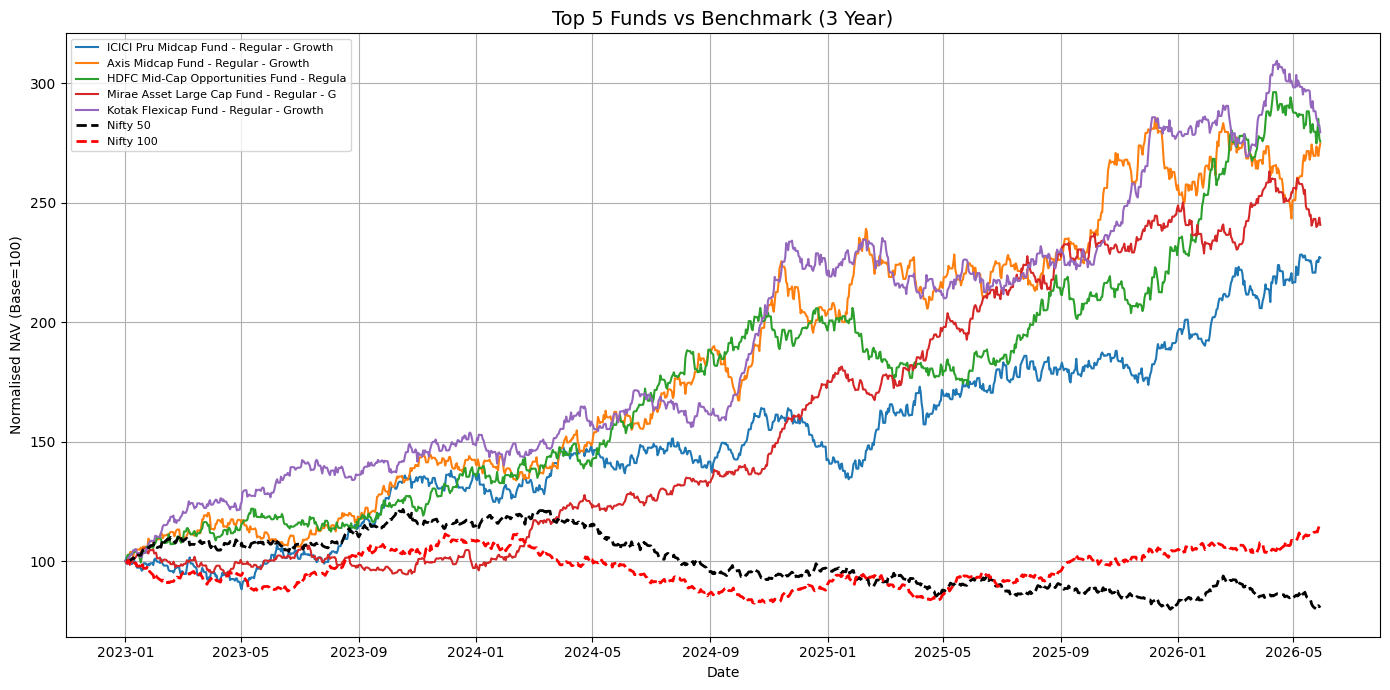

Chart saved!

Tracking Error vs Nifty 100:
  ICICI Pru Midcap Fund - Regular - Growth: 0.2322
  Axis Midcap Fund - Regular - Growth: 0.2404
  HDFC Mid-Cap Opportunities Fund - Regular - G: 0.2267
  Mirae Asset Large Cap Fund - Regular - Growth: 0.1874
  Kotak Flexicap Fund - Regular - Growth: 0.2070


In [10]:
# Fix normalise function
def normalise(series):
    arr = np.array(series)
    return (arr / arr[0]) * 100

plt.figure(figsize=(14, 7))

for code, name in zip(top5_codes, top5_names):
    fund_nav = nav[(nav['amfi_code'] == code) & (nav['date'] >= start)].copy()
    fund_nav = fund_nav.sort_values('date')
    plt.plot(fund_nav['date'], normalise(fund_nav['nav'].values), label=name[:40])

plt.plot(nifty50['date'], normalise(nifty50['close_value'].values),
         'k--', linewidth=2, label='Nifty 50')
plt.plot(nifty100['date'], normalise(nifty100['close_value'].values),
         'r--', linewidth=2, label='Nifty 100')

plt.title('Top 5 Funds vs Benchmark (3 Year)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Normalised NAV (Base=100)')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/benchmark_comparison.png', dpi=150)
plt.show()
print("Chart saved!")

# Tracking error
print("\nTracking Error vs Nifty 100:")
for code, name in zip(top5_codes, top5_names):
    fund_nav = nav[(nav['amfi_code'] == code) & (nav['date'] >= start)].copy()
    merged = pd.merge(fund_nav[['date','daily_return']],
                      nifty100[['date']].assign(
                          bench_return=nifty100['close_value'].pct_change().values),
                      on='date').dropna()
    te = (merged['daily_return'] - merged['bench_return']).std() * np.sqrt(252)
    print(f"  {name[:45]}: {te:.4f}")

In [11]:
import shutil

# Save alpha_beta.csv
ab_df.to_csv("/content/alpha_beta.csv", index=False)

# Copy files to Drive
REPORTS = Path("/content/drive/MyDrive/bluestock_mf_capstone/reports")
REPORTS.mkdir(parents=True, exist_ok=True)

shutil.copy("/content/fund_scorecard.csv",
            "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/fund_scorecard.csv")
shutil.copy("/content/alpha_beta.csv",
            "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/alpha_beta.csv")
shutil.copy("/content/benchmark_comparison.png",
            str(REPORTS / "benchmark_comparison.png"))

print("All files saved to Drive!")

All files saved to Drive!
